In [1]:
!uv pip install seaborn mlxtend --quiet

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
df = pd.read_csv('./../datasets/Iris.csv')

In [4]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
df = df.iloc[:,1:]

In [6]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [7]:
from sklearn.preprocessing import LabelEncoder

In [8]:
encoder = LabelEncoder()

In [9]:
df['Species'] = encoder.fit_transform(df['Species'])

In [10]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [11]:
df = df[df['Species'] != 0][['SepalWidthCm','PetalLengthCm','Species']]

In [12]:
df.head()

,SepalWidthCm,PetalLengthCm,Species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

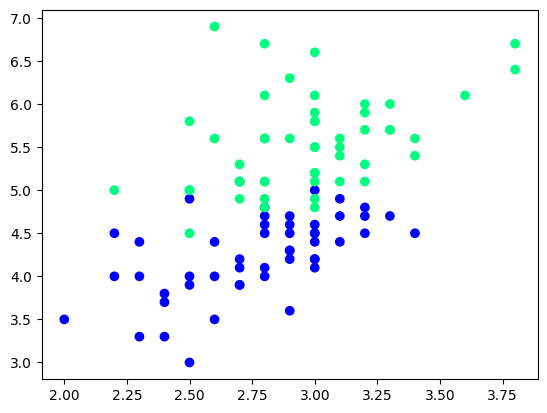

In [14]:
plt.scatter(df['SepalWidthCm'],df['PetalLengthCm'],c=df['Species'],cmap='winter')

In [15]:
df_train = df.iloc[:60,:].sample(10)
df_train

,SepalWidthCm,PetalLengthCm,Species
76,2.8,4.8,1
107,2.9,6.3,2
78,2.9,4.5,1
58,2.9,4.6,1
54,2.8,4.6,1
50,3.2,4.7,1
71,2.8,4.0,1
87,2.3,4.4,1
93,2.3,3.3,1
105,3.0,6.6,2


In [16]:
# Taking only 10 rows for training
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [17]:
df_train

,SepalWidthCm,PetalLengthCm,Species
144,3.3,5.7,2
120,3.2,5.7,2
109,3.6,6.1,2
114,2.8,5.1,2
119,2.2,5.0,2
76,2.8,4.8,1
83,2.7,5.1,1
136,3.4,5.6,2
54,2.8,4.6,1
58,2.9,4.6,1


In [18]:
df_val

,SepalWidthCm,PetalLengthCm,Species
85,3.4,4.5,1
130,2.8,6.1,2
106,2.5,4.5,2
99,2.8,4.1,1
60,2.0,3.5,1


In [19]:
df_test

,SepalWidthCm,PetalLengthCm,Species
84,3.0,4.5,1
67,2.7,4.1,1
125,3.2,6.0,2
62,2.2,4.0,1
140,3.1,5.6,2


In [20]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [21]:
y_test

array([1, 2, 2, 1, 1])

# Case 1 - Bagging

In [22]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,SepalWidthCm,PetalLengthCm,Species
54,2.8,4.6,1
83,2.7,5.1,1
119,2.2,5.0,2
114,2.8,5.1,2
120,3.2,5.7,2
144,3.3,5.7,2
109,3.6,6.1,2
136,3.4,5.6,2


In [23]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [24]:
dt_bag1 = DecisionTreeClassifier()

In [25]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))
    

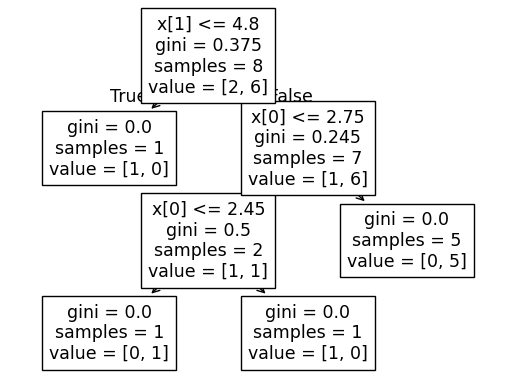

0.8


/Users/kevin/Desktop/ai-engineer/machine-learning/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/Users/kevin/Desktop/ai-engineer/machine-learning/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


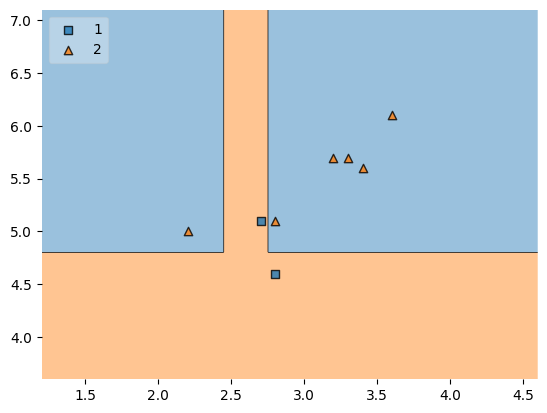

In [26]:
evaluate(dt_bag1,X,y)

In [27]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
119,2.2,5.0,2
109,3.6,6.1,2
54,2.8,4.6,1
58,2.9,4.6,1
144,3.3,5.7,2
136,3.4,5.6,2
114,2.8,5.1,2
136,3.4,5.6,2


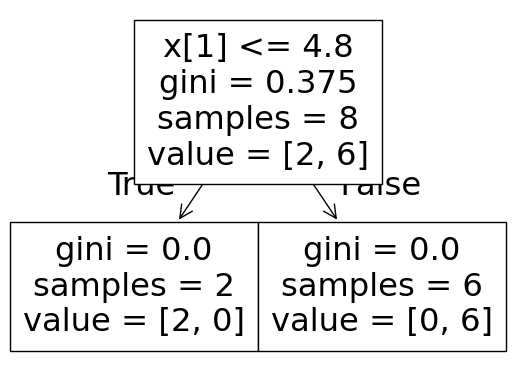

0.8


/Users/kevin/Desktop/ai-engineer/machine-learning/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/Users/kevin/Desktop/ai-engineer/machine-learning/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


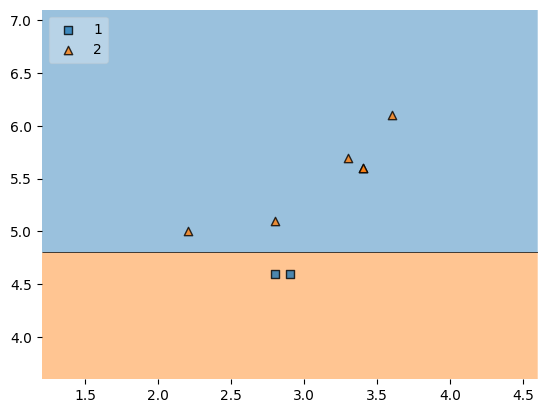

In [28]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [29]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
119,2.2,5.0,2
136,3.4,5.6,2
54,2.8,4.6,1
120,3.2,5.7,2
83,2.7,5.1,1
114,2.8,5.1,2
58,2.9,4.6,1
76,2.8,4.8,1


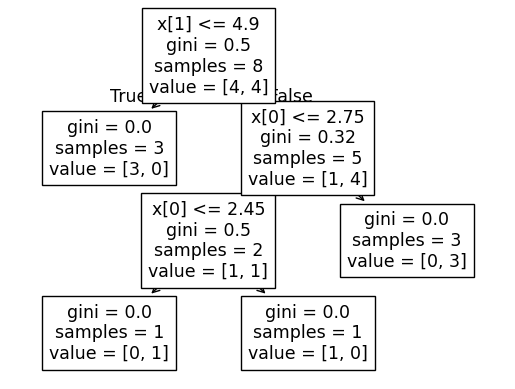

/Users/kevin/Desktop/ai-engineer/machine-learning/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/Users/kevin/Desktop/ai-engineer/machine-learning/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.8


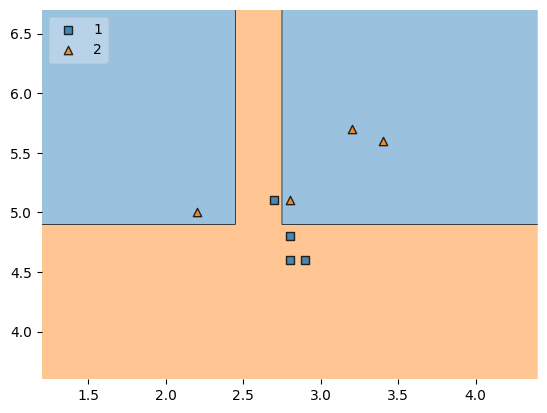

In [30]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

## Predict

In [31]:
df_test

,SepalWidthCm,PetalLengthCm,Species
84,3.0,4.5,1
67,2.7,4.1,1
125,3.2,6.0,2
62,2.2,4.0,1
140,3.1,5.6,2


In [32]:
print("Predictor 1",dt_bag1.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([2.2,5.0]).reshape(1,2)))

Predictor 1 [2]
Predictor 2 [2]
Predictor 3 [2]


/Users/kevin/Desktop/ai-engineer/machine-learning/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/Users/kevin/Desktop/ai-engineer/machine-learning/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/Users/kevin/Desktop/ai-engineer/machine-learning/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


# Pasting

In [33]:
# Row sampling without replacement
df_train

,SepalWidthCm,PetalLengthCm,Species
144,3.3,5.7,2
120,3.2,5.7,2
109,3.6,6.1,2
114,2.8,5.1,2
119,2.2,5.0,2
76,2.8,4.8,1
83,2.7,5.1,1
136,3.4,5.6,2
54,2.8,4.6,1
58,2.9,4.6,1


In [34]:
df_train.sample(8)

,SepalWidthCm,PetalLengthCm,Species
58,2.9,4.6,1
54,2.8,4.6,1
114,2.8,5.1,2
109,3.6,6.1,2
76,2.8,4.8,1
119,2.2,5.0,2
83,2.7,5.1,1
144,3.3,5.7,2


# Random Subspaces

In [35]:
df1 = pd.read_csv('./../datasets/Iris.csv')
df1 = df1.sample(10)

In [36]:
df1

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
68,69,6.2,2.2,4.5,1.5,Iris-versicolor
33,34,5.5,4.2,1.4,0.2,Iris-setosa
0,1,5.1,3.5,1.4,0.2,Iris-setosa
128,129,6.4,2.8,5.6,2.1,Iris-virginica
76,77,6.8,2.8,4.8,1.4,Iris-versicolor
2,3,4.7,3.2,1.3,0.2,Iris-setosa
82,83,5.8,2.7,3.9,1.2,Iris-versicolor
133,134,6.3,2.8,5.1,1.5,Iris-virginica
110,111,6.5,3.2,5.1,2.0,Iris-virginica
109,110,7.2,3.6,6.1,2.5,Iris-virginica


In [37]:
df1.sample(2,replace=True,axis=1)

,PetalLengthCm,PetalLengthCm
68,4.5,4.5
33,1.4,1.4
0,1.4,1.4
128,5.6,5.6
76,4.8,4.8
2,1.3,1.3
82,3.9,3.9
133,5.1,5.1
110,5.1,5.1
109,6.1,6.1


# Random Patches

In [38]:
df1

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
68,69,6.2,2.2,4.5,1.5,Iris-versicolor
33,34,5.5,4.2,1.4,0.2,Iris-setosa
0,1,5.1,3.5,1.4,0.2,Iris-setosa
128,129,6.4,2.8,5.6,2.1,Iris-virginica
76,77,6.8,2.8,4.8,1.4,Iris-versicolor
2,3,4.7,3.2,1.3,0.2,Iris-setosa
82,83,5.8,2.7,3.9,1.2,Iris-versicolor
133,134,6.3,2.8,5.1,1.5,Iris-virginica
110,111,6.5,3.2,5.1,2.0,Iris-virginica
109,110,7.2,3.6,6.1,2.5,Iris-virginica


In [39]:
df1.sample(8,replace=True).sample(2,replace=True,axis=1)

,PetalLengthCm,SepalLengthCm
110,5.1,6.5
133,5.1,6.3
109,6.1,7.2
82,3.9,5.8
128,5.6,6.4
33,1.4,5.5
109,6.1,7.2
82,3.9,5.8
